# 01 — Calibrate detection on ONE slice

Tune detection on a single section, inspect it against the QC gates, then **lock** the
parameters into `BraiAn.yml` so `02_batch.ipynb` can apply them to the whole series.
This is the pipeline's own rule from `CLAUDE.md`: *tune on ONE section before scaling*.

**Cost split — this is the whole design.**

| | cost | what |
|---|---|---|
| **EXPENSIVE** | ~30 min/slice, QuPath JVM | DAPI detection + measurement export |
| **CHEAP** | seconds, pure pandas | gates, histograms, densities, k-sweep |

There is deliberately **no live slider** on detection parameters — at 30 min a run that
would be theatre. The loop is **tune → run → inspect**.

Expensive cells honour `PARAMS["dry_run"]` and default to **printing** the exact headless
command rather than launching anything. Run this notebook in the `braian` env.

## PARAMS — the only cell you edit

In [1]:
PARAMS = {
    # QuPath project holding BraiAn.yml, pipeline.yml, scripts/ and results/
    "project": "/home/jflab/Analysis/wBA 1-3 2-1 072026/wBA_1-3_2-1_072026",

    # Which slice to calibrate on. None -> first slice found in results/.
    "slice": None,

    # Safety. True = expensive cells only PRINT their command. Flip deliberately.
    "dry_run": True,

    # Candidate detection params to try. Keys must exist in BraiAn.yml.
    # Empty dict = inspect the params already in BraiAn.yml without changing them.
    "detection": {
        # "sigmaMicrons": 2.0,
        # "minAreaMicrons": 20.0,
        # "maxAreaMicrons": 250.0,
        # "histogramThreshold.nPeak": 2,
    },

    # Final gate: set True only once the QC section below looks right.
    "lock": False,

    # Gate threshold overrides, e.g. {"area_peak_min": 25.0}. See GateThresholds.
    # white_matter/ventricle demoted to advisory 2026-07-28 (operator call): they still
    # report their numbers but no longer drive the verdict. Consequence: DAPI DENSITIES
    # are not trustworthy while this holds; ratio readouts like P(Fos+|TdT+) are fine.
    # Remove the advisory_gates entry to re-arm them.
    "thresholds": {
        "advisory_gates": ("white_matter_density", "ventricle_density"),
    },
}

import sys
from dataclasses import replace
from pathlib import Path

sys.path.insert(0, str(Path("/home/jflab/Analysis/scripts")))

# ipykernel in this env does not auto-activate the inline backend, so matplotlib
# falls back to the non-interactive Agg canvas and plt.show() silently renders
# nothing ("FigureCanvasAgg is non-interactive"). Make it explicit.
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cockpit_checks as cc
import cockpit_threshold as ct

PROJECT = Path(PARAMS["project"])
TH = replace(cc.DEFAULT_THRESHOLDS, **PARAMS["thresholds"])
print(f"project : {PROJECT}\ndry_run : {PARAMS['dry_run']}")

project : /home/jflab/Analysis/wBA 1-3 2-1 072026/wBA_1-3_2-1_072026
dry_run : True


## 1. Config panel — what is currently set

Everything below is read from `pipeline.yml` and `BraiAn.yml`; nothing is hardcoded.

In [2]:
config = cc.load_config(PROJECT)
anchor_ch = cc.anchor_channel(PROJECT)

print("pipeline.yml")
print(f"  anchor   : {config.anchor_name}  (channel {anchor_ch})")
for m in config.markers:
    print(f"  marker   : {m['name']:<6} channel {m['channel']:<12} compartment {m['compartment']}")
print(f"  Double+  : {'yes' if config.emit_double else 'no (needs >=2 markers)'}")
print(f"  exclude  : {sorted(config.exclude_acronyms) or '(none)'}")
print(f"  k_robust : {cc.k_robust(PROJECT):g}")

print("\nBraiAn.yml detection params (what the gates below are judging)")
current = cc.detection_params(PROJECT)
for k, v in current.items():
    marker = "  <- PARAMS override" if k in PARAMS["detection"] else ""
    print(f"  {k:<34} {v}{marker}")

if PARAMS["detection"]:
    print("\nProposed changes:")
    for k, v in PARAMS["detection"].items():
        print(f"  {k:<34} {current.get(k)}  ->  {v}")
else:
    print("\nNo overrides in PARAMS['detection'] — inspecting BraiAn.yml as-is.")

pipeline.yml
  anchor   : DAPI  (channel DAPI-T4)
  marker   : Fos    channel AF488-T3     compartment nuclear
  marker   : TdT    channel AF568-T2     compartment whole-cell
  Double+  : yes
  exclude  : ['DG-sg', 'VS']
  k_robust : 3

BraiAn.yml detection params (what the gates below are judging)
  channel                            DAPI-T4
  classForDetections                 allen_mouse_10um_java
  requestedPixelSizeMicrons          0.6905355
  sigmaMicrons                       2.0
  minAreaMicrons                     20.0
  maxAreaMicrons                     250.0
  cellExpansionMicrons               5.0
  backgroundRadiusMicrons            10
  medianRadiusMicrons                0.0
  watershedPostProcess               True
  histogramThreshold.resolutionLevel 0
  histogramThreshold.smoothWindowSize 15
  histogramThreshold.peakProminence  500
  histogramThreshold.nPeak           2

No overrides in PARAMS['detection'] — inspecting BraiAn.yml as-is.


## 2. Pick the calibration slice

In [3]:
slices = cc.find_slices(PROJECT)
print(f"{len(slices)} slice(s) with exports in results/:")
for s in slices:
    print(f"  {s.label:<24} regions={'y' if s.regions_tsv else '-'} "
          f"percell={'y' if s.percell_tsv else '-'}")

if PARAMS["slice"]:
    hits = [s for s in slices if s.label == PARAMS["slice"]]
    if not hits:
        raise SystemExit(f"slice {PARAMS['slice']!r} not found; choose from "
                         f"{[s.label for s in slices]}")
    SLICE = hits[0]
else:
    SLICE = slices[0]

# Map the slice back to its QuPath image entry name (what --image expects).
IMAGE = next((n for n in cc.project_image_names(PROJECT) if n.endswith(SLICE.label)), None)
print(f"\ncalibrating on : {SLICE.label}")
print(f"QuPath entry   : {IMAGE or '(not matched in project.qpproj)'}")

5 slice(s) with exports in results/:
  wBA1-3_s1                regions=y percell=y
  wBA1-3_s2                regions=y percell=y
  wBA1-3_s3                regions=y percell=y
  wBA1-3_s4                regions=y percell=y
  wBA1-3_s5                regions=y percell=y

calibrating on : wBA1-3_s1
QuPath entry   : wBA1-3_s1_MIP.ome.tiff - wBA1-3_s1


## 3. Detection threshold — calibrate & visualize &nbsp;<sub>EXPENSIVE, then CHEAP</sub>

The anchor-channel intensity cut that decides which pixels are a nucleus. This replaces
the old `find_threshold().groovy` sweep, which hardwired the channel name and swept
`peakProminence` — a knob that changes *which peak is found*, not where the cut sits.

**The rule** (`detection_threshold` in `pipeline.yml`):

$$\text{threshold} = \text{floor} + \texttt{span\_frac} \times (\text{bright peak} - \text{floor})$$

Both endpoints are re-measured from **each section's own histogram**, so the cut follows
staining and laser drift instead of being pinned to whichever section it was tuned on.
That is what keeps counts comparable across sections, animals and acquisitions — and it
is why a fixed absolute threshold (the previous `threshold: 700`) had to go.

`calibrate_threshold.groovy` is read-only: it changes no objects and is safe to re-run.
It writes `<image>__threshold_calibration.json`, which the next cell plots.

**Reading the plot.** Shaded band = floor → bright peak. Solid red line = the chosen cut.
Too near the floor and background is detected as nuclei; too near the bright peak and dim
real nuclei are dropped — the failure mode the reference workflow reports as destroying
regional contrast. The lower quarter of the span is the working range.


In [ ]:
# EXPENSIVE — runs QuPath on one slice. Read-only: no objects are modified.
calib_script = PROJECT / "scripts" / "calibrate_threshold.groovy"

if not calib_script.exists():
    print(f"calibrate_threshold.groovy not deployed in {PROJECT/'scripts'}.")
    print("Deploy the pipeline into this project (also removes retired scripts):")
    print(f'  python3 /home/jflab/Analysis/scripts/sync_project.py --project "{PROJECT}"')
else:
    calib_cmd = cc.qupath_command(PROJECT, calib_script, image=IMAGE, save=False)
    cc.run_qupath(calib_cmd, dry_run=PARAMS["dry_run"],
                  log_path=PROJECT / "results" / f"{SLICE.label}__threshold_calibration.log")

print("\nThreshold rule currently configured in pipeline.yml:")
_cfg = ct.load_config_threshold(PROJECT)
for k, v in _cfg.items():
    print(f"  {k:<18} {v}")


In [ ]:
# CHEAP — pure pandas/matplotlib over the calibration JSONs already on disk.
calibs = ct.find_calibrations(PROJECT)

if not calibs:
    print("No *__threshold_calibration.json in results/ yet.")
    print("Run the cell above with dry_run=False (or run calibrate_threshold.groovy in QuPath).")
else:
    ct.print_report(PROJECT)

    # This slice: where the cut lands on the real histogram, and what the knob would do.
    this = next((c for c in calibs if SLICE.label in c.image), calibs[0])
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.2),
                             gridspec_kw={"width_ratios": [1.75, 1]})
    ct.plot_histogram(this, ax=axes[0])
    ct.plot_sweep(this, ax=axes[1])
    plt.tight_layout()
    plt.show()

    # Whole series: a section whose floor/bright peak is unlike its siblings is an
    # acquisition inconsistency, worth catching before spending a batch run on it.
    if len(calibs) > 1:
        ct.plot_series(calibs)
        plt.tight_layout()
        plt.show()


## 4. Detect this one slice &nbsp;<sub>EXPENSIVE — ~30 min</sub>

Writes `PARAMS["detection"]` into `BraiAn.yml` (**after backing it up**), then runs
detection → classification → export on this slice alone. `--save` is included: without it
QuPath discards the result and the half-hour is wasted.

In [5]:
if PARAMS["detection"] and not PARAMS["dry_run"]:
    yml, bak = cc.lock_detection_params(PROJECT, PARAMS["detection"])
    print(f"staged params into {yml.name}   (backup: {bak.name})")
elif PARAMS["detection"]:
    print("DRY RUN — would stage into BraiAn.yml (backup first):")
    for k, v in PARAMS["detection"].items():
        print(f"    {k} = {v}")
else:
    print("No PARAMS['detection'] overrides — using BraiAn.yml as-is.")

STAGES = ["run_braian_detection.groovy", "02_detect_classify.groovy",
          "03_export_region_table.groovy"]

print(f"\nPipeline for {SLICE.label} ({len(STAGES)} stages):")
for script in STAGES:
    cmd = cc.qupath_command(PROJECT, script, image=IMAGE)
    rc = cc.run_qupath(cmd, dry_run=PARAMS["dry_run"],
                       log_path=PROJECT / "results" / f"{SLICE.label}__{Path(script).stem}.log")
    if rc > 0:
        raise RuntimeError(f"{script} failed with exit {rc} — see the log above")

No PARAMS['detection'] overrides — using BraiAn.yml as-is.

Pipeline for wBA1-3_s1 (3 stages):
DRY RUN -- would execute:
  /home/jflab/section-pipeline/tools/QuPath/bin/QuPath script -p '/home/jflab/Analysis/wBA 1-3 2-1 072026/wBA_1-3_2-1_072026/project.qpproj' -i 'wBA1-3_s1_MIP.ome.tiff - wBA1-3_s1' -s '/home/jflab/Analysis/wBA 1-3 2-1 072026/wBA_1-3_2-1_072026/scripts/run_braian_detection.groovy'
DRY RUN -- would execute:
  /home/jflab/section-pipeline/tools/QuPath/bin/QuPath script -p '/home/jflab/Analysis/wBA 1-3 2-1 072026/wBA_1-3_2-1_072026/project.qpproj' -i 'wBA1-3_s1_MIP.ome.tiff - wBA1-3_s1' -s '/home/jflab/Analysis/wBA 1-3 2-1 072026/wBA_1-3_2-1_072026/scripts/02_detect_classify.groovy'
DRY RUN -- would execute:
  /home/jflab/section-pipeline/tools/QuPath/bin/QuPath script -p '/home/jflab/Analysis/wBA 1-3 2-1 072026/wBA_1-3_2-1_072026/project.qpproj' -i 'wBA1-3_s1_MIP.ome.tiff - wBA1-3_s1' -s '/home/jflab/Analysis/wBA 1-3 2-1 072026/wBA_1-3_2-1_072026/scripts/03_export_regio

## 5. QC self-checks &nbsp;<sub>CHEAP</sub>

Each gate prints its measured **number** next to a PASS/FLAG verdict. Advisory gates
inform but never decide the overall verdict.

In [6]:
results = cc.run_all_gates(SLICE, PROJECT, TH, config, anchor_ch)
cc.print_gates(SLICE.label, results)

blocking = [r for r in results if r.is_flag and not r.advisory]
print("\n" + ("All blocking gates PASS — parameters look sane on this slice."
              if not blocking else
              "Blocking gate(s) flagged: " + ", ".join(r.name for r in blocking)
              + "\nAdjust PARAMS['detection'] and re-run section 4, or — if the number is"
                "\nright for this prep and the BAND is what is wrong — widen it via"
                "\nPARAMS['thresholds'] and record why."))


wBA1-3_s1  ->  PASS
  [            PASS] nucleus_area_peak_um2      =       27.5   modal bin of 195,823 nuclei; expect 25-150 um^2
  [            PASS] k_swing_pp                 =        1.5   P(Fos+|TdT+) [k=2:42.2%, k=2.5:41.9%, k=3:40.7%]; max swing 10 pp
  [ FLAG (advisory)] white_matter_density       =    4,774.2   worst='cc' 4,774/mm^2 vs cortex 4,048/mm^2 (ratio 1.18)  <-- 1.18x cortex > 0.6x; > 1500/mm^2; DAPI haze likely  [demoted to advisory]
  [ FLAG (advisory)] ventricle_density          =    1,317.8   'VS'; expect <= 500/mm^2  <-- detections inside ventricle  [demoted to advisory]
  [ FLAG (advisory)] grey_density_median        =    4,048.0   0/7 regions inside 500-2000/mm^2 (Isocortex 4,048, CA1 3,151, CA3 3,333, DG 3,275, TH 4,242, HY 4,800, STR 4,350)
  [            PASS] total_density              =    4,106.4   195,816 detections over 47.7 mm^2 registered; expect 300-8000/mm^2

All blocking gates PASS — parameters look sane on this slice.


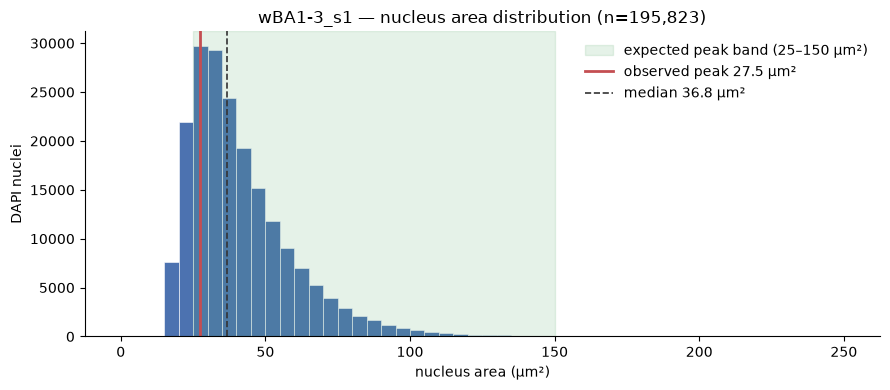

In [7]:
# Nucleus area histogram — the shape behind the area gate.
percell = cc.load_percell_for_slice(SLICE)
areas = pd.to_numeric(percell["nucleus_area_um2"], errors="coerce")
areas = areas[np.isfinite(areas) & (areas > 0)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(areas, bins=np.arange(0, min(areas.max(), TH.area_peak_max * 4) + TH.area_bin_width,
                              TH.area_bin_width), color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.axvspan(TH.area_peak_min, TH.area_peak_max, color="#55A868", alpha=0.15,
           label=f"expected peak band ({TH.area_peak_min:g}–{TH.area_peak_max:g} µm²)")
peak = next(r for r in results if r.name == "nucleus_area_peak_um2").value
if np.isfinite(peak):
    ax.axvline(peak, color="#C44E52", lw=2, label=f"observed peak {peak:.1f} µm²")
ax.axvline(float(areas.median()), color="#333", lw=1.2, ls="--",
           label=f"median {areas.median():.1f} µm²")
ax.set(xlabel="nucleus area (µm²)", ylabel=f"{config.anchor_name} nuclei",
       title=f"{SLICE.label} — nucleus area distribution (n={len(areas):,})")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

region,count,area_mm2,density_per_mm2
Isocortex,"60,055",14.836,"4,048"
cc,"5,595",1.172,"4,774"
int,"3,536",0.774,"4,568"
fiber tracts,"21,047",4.576,"4,599"
VS,930,0.706,"1,318"


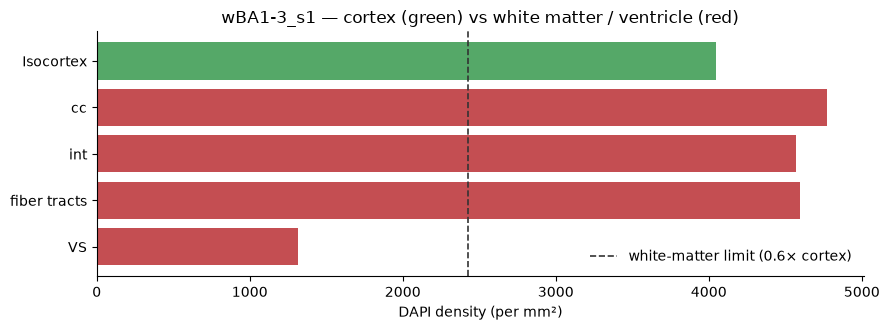

In [8]:
# Region densities behind the white-matter / ventricle gates.
if SLICE.regions_tsv is not None:
    regions = cc.load_regions_tsv(SLICE.regions_tsv, anchor_ch)
    show = list(TH.cortex_acronyms) + list(TH.white_matter_acronyms) + list(TH.ventricle_acronyms)
    rows = [(a, *cc.region_density(regions, a)) for a in show]
    rows = [(a, c, ar, d) for a, c, ar, d in rows if np.isfinite(d)]
    dens = pd.DataFrame(rows, columns=["region", "count", "area_mm2", "density_per_mm2"])
    display(dens.style.format({"count": "{:,.0f}", "area_mm2": "{:.3f}",
                               "density_per_mm2": "{:,.0f}"}).hide(axis="index"))

    cortex = np.mean([cc.region_density(regions, a)[2] for a in TH.cortex_acronyms])
    fig, ax = plt.subplots(figsize=(9, 3.4))
    colors = ["#55A868" if r in TH.cortex_acronyms else "#C44E52" for r in dens["region"]]
    ax.barh(dens["region"], dens["density_per_mm2"], color=colors)
    ax.axvline(cortex * TH.white_matter_ratio_max, color="#333", ls="--", lw=1.2,
               label=f"white-matter limit ({TH.white_matter_ratio_max:g}× cortex)")
    ax.set(xlabel=f"{config.anchor_name} density (per mm²)",
           title=f"{SLICE.label} — cortex (green) vs white matter / ventricle (red)")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("no regions.tsv for this slice — density plot skipped")

## 6. Lock the parameters

Commits `PARAMS["detection"]` into `BraiAn.yml` so `02_batch.ipynb` applies exactly these
numbers to every slice. The file is backed up first, values are edited **in place** so the
comments recording *why* each number is what it is survive, and every write is verified by
re-parsing. Requires `PARAMS["lock"] = True` — an explicit, deliberate act.

In [9]:
if not PARAMS["lock"]:
    print("PARAMS['lock'] is False — nothing written.")
    print("Set it True (with PARAMS['detection'] filled in) once the gates above look right.")
elif not PARAMS["detection"]:
    print("PARAMS['lock'] is True but PARAMS['detection'] is empty — nothing to lock.")
elif blocking:
    print("Refusing to lock: blocking gate(s) still flagged — "
          + ", ".join(r.name for r in blocking))
    print("Fix the parameters, or widen the band in PARAMS['thresholds'] if the band is "
          "what is wrong, then re-run.")
else:
    yml, bak = cc.lock_detection_params(PROJECT, PARAMS["detection"])
    print(f"LOCKED into {yml}\nbackup   {bak}")
    for k, v in cc.detection_params(PROJECT).items():
        print(f"  {k:<34} {v}{'  <- locked' if k in PARAMS['detection'] else ''}")
    print("\nNext: run 02_batch.ipynb to apply these to the whole series.")

PARAMS['lock'] is False — nothing written.
Set it True (with PARAMS['detection'] filled in) once the gates above look right.
